# 00  Exploration

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CONFIG_PATH = PROJECT_ROOT / "configs" / "default.yaml"
with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

PROCESSED_DIR = PROJECT_ROOT / cfg["data"]["processed_dir"]
sys.path.insert(0, str(PROJECT_ROOT / "src"))

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (14, 5), "figure.dpi": 100})

print(f"Project root:  {PROJECT_ROOT}")
print(f"Processed dir: {PROCESSED_DIR}")

Project root:  c:\Users\vonae\Desktop\ESILV\PERGAM project\Pergam_MSc_2026 EDO
Processed dir: c:\Users\vonae\Desktop\ESILV\PERGAM project\Pergam_MSc_2026 EDO\data\processed\stoxx600


## Load processed data

Produced by `01_data_loading.ipynb`:
- `stoxx600_processed.csv`, in long format: (`date`, `ticker`, `price`, `*_arith_ret`, `*_log_ret`, `*_arith_ret_rel`, `*_vol`, `60d_ewm_vol`, `*_std_ret`, `sector`, `country`, `region`, `is_ffilled`, `is_stale`)
- `benchmark_stoxx600_ew.csv` stacked: (`date`, `benchmark` ∈ {SXXR, EW}, `price`)

In [2]:
stocks = pd.read_csv(PROCESSED_DIR / "stoxx600_processed.csv", parse_dates=["date"])
benchmarks = pd.read_csv(PROCESSED_DIR / "benchmark_stoxx600_ew.csv", parse_dates=["date"])
stocks.tail()

,date,ticker,price,1d_arith_ret,1d_log_ret,21d_arith_ret,21d_log_ret,252d_arith_ret,252d_log_ret,1d_arith_ret_rel,...,252d_std_ret,macd_8_24,macd_16_28,macd_32_96,sector,exchange,country,region,is_ffilled,is_stale
2391725,2026-05-06,WKL NA,63.42,-0.073349,-0.076178,-0.020087,-0.020291,-0.602756,-0.923205,-0.080344,...,-3.366667,-0.001825,0.043417,-4.320866,Information Technology,NaN,Netherlands,Western Europe,False,False
2391726,2026-05-06,WPP LN,274.15,0.003477,0.003471,0.111719,0.105908,-0.542168,-0.781252,-0.002453,...,0.220229,0.962812,0.523045,-2.366958,Communication Services,LN,United Kingdom,UK & Ireland,False,False
2391727,2026-05-06,WRT1V FH,37.00,0.028063,0.027677,0.136364,0.127833,1.048159,0.716942,-0.003325,...,1.175254,0.503198,0.485527,1.948040,Industrials,FH,Finland,Nordic,False,False
2391728,2026-05-06,WTB LN,2346.00,0.035762,0.035137,-0.018410,-0.018582,-0.174525,-0.191796,-0.003738,...,1.906433,-1.111058,-0.528936,-2.300734,Consumer Discretionary,LN,United Kingdom,UK & Ireland,False,False
2391729,2026-05-06,YAR NO,529.60,-0.041968,-0.042874,-0.112601,-0.119460,0.466224,0.382690,-0.069251,...,-2.377114,-0.025455,0.115273,2.675904,Materials,NO,Norway,Nordic,False,False


## Data quality checks

Total unique dates:        5308
Ticker coverage:           min=50, median=3134, max=5308
Tickers with full history: 152 / 776


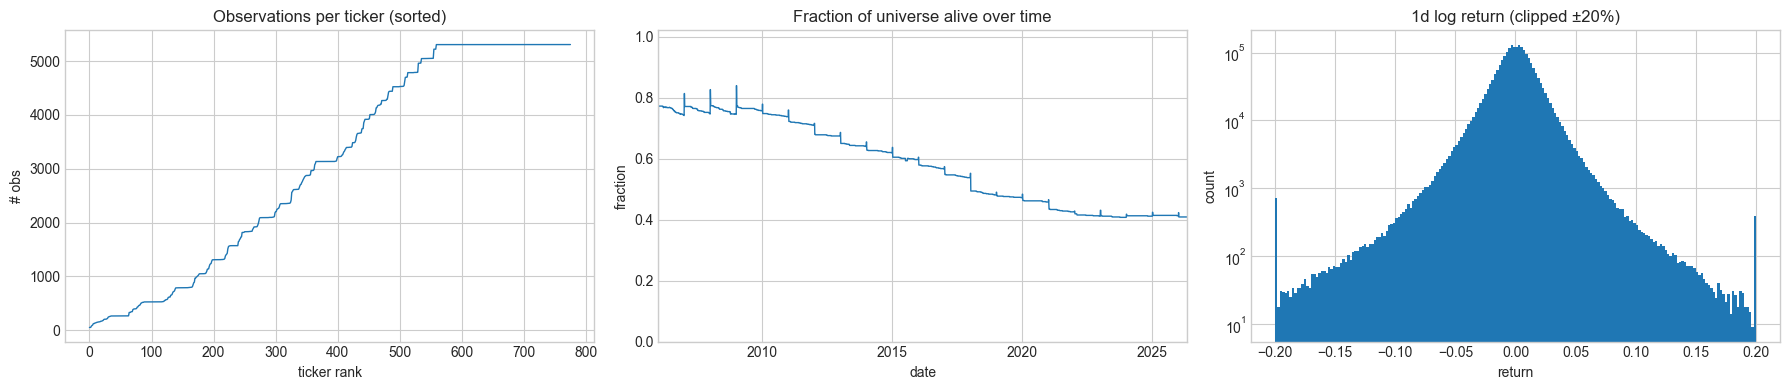

In [3]:
coverage = stocks.groupby("ticker")["date"].count().sort_values()
n_dates = stocks["date"].nunique()
alive = stocks.groupby("date")["ticker"].nunique() / stocks["ticker"].nunique()

print(f"Total unique dates:        {n_dates}")
print(f"Ticker coverage:           min={coverage.min()}, median={int(coverage.median())}, max={coverage.max()}")
print(f"Tickers with full history: {(coverage == n_dates).sum()} / {len(coverage)}")

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
coverage.reset_index(drop=True).plot(ax=axes[0], linewidth=1)
axes[0].set_title("Observations per ticker (sorted)")
axes[0].set_xlabel("ticker rank"); axes[0].set_ylabel("# obs")

alive.plot(ax=axes[1], linewidth=1)
axes[1].set_title("Fraction of universe alive over time")
axes[1].set_ylabel("fraction"); axes[1].set_ylim(0, 1.02)

stocks["1d_log_ret"].dropna().clip(-0.2, 0.2).hist(ax=axes[2], bins=200)
axes[2].set_title("1d log return (clipped ±20%)")
axes[2].set_xlabel("return"); axes[2].set_ylabel("count")
axes[2].set_yscale("log")
plt.tight_layout(); plt.show()

## Single-stock sanity

Price and realized volatility 

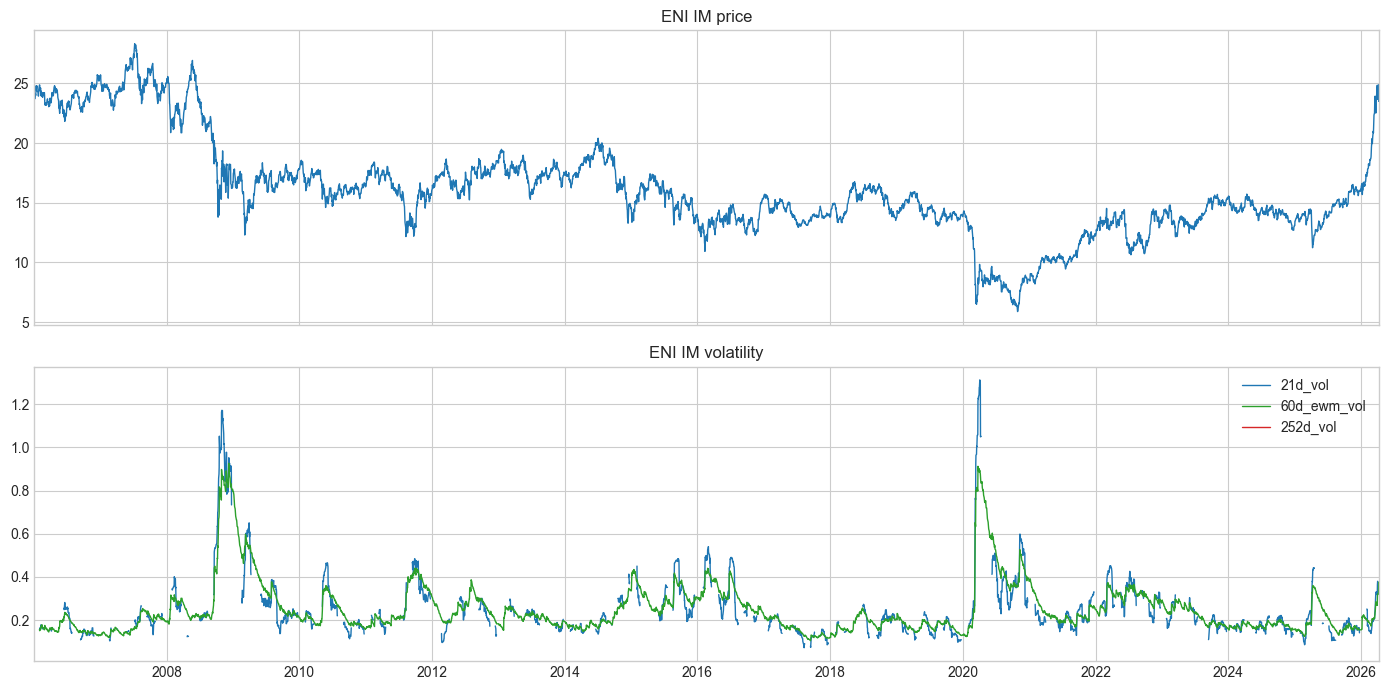

In [4]:
TICKER = "ENI IM" # some examples: ASML NA, SAP GY, AZN LN, ENI IM, SAN FP, TTE FP, HSBA LN

one = stocks.loc[stocks["ticker"] == TICKER].set_index("date").sort_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(one.index, one["price"], linewidth=1)
axes[0].set_title(f"{TICKER} price")
axes[0].set_xlim(pd.to_datetime('2006-01-02'), pd.to_datetime('2026-04-10'))

for col, color in [("21d_vol", "tab:blue"), ("60d_ewm_vol", "tab:green"), ("252d_vol", "tab:red")]:
    if col in one.columns:
        axes[1].plot(one.index, one[col], linewidth=1, label=col, color=color)
axes[1].set_title(f"{TICKER} volatility")
axes[1].legend()
plt.tight_layout()
plt.show()

Arithmetic, log, sector-relative and standardized returns for all the available horizons

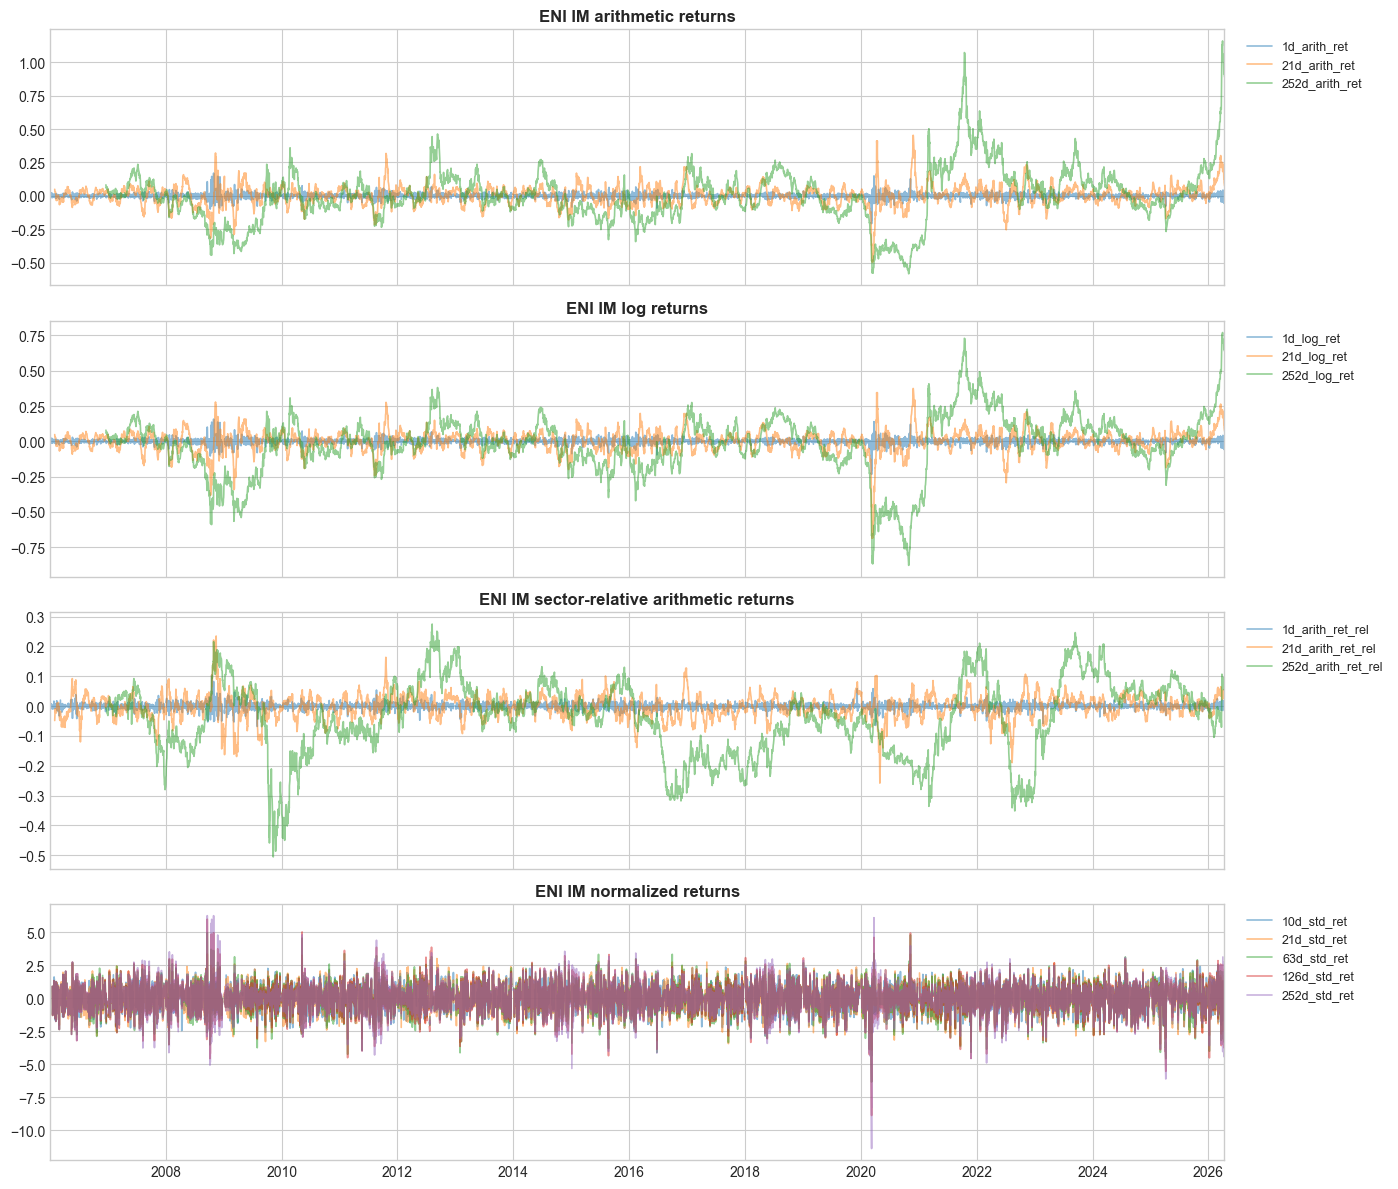

In [5]:
time_series_configs = [
    {"title": "arithmetic returns", "suffix": "_arith_ret"},
    {"title": "log returns", "suffix": "_log_ret"},
    {"title": "sector-relative arithmetic returns", "suffix": "_arith_ret_rel"}, 
    {"title": "normalized returns", "suffix": "_std_ret"} 
]

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

for i, config in enumerate(time_series_configs):
    ax = axes[i]
    
    cols = [c for c in one.columns if c.endswith(config["suffix"])]
    
    for c in cols:
        ax.plot(one.index, one[c], linewidth=1.2, alpha=0.5, label=c)
        
    ax.set_title(f"{TICKER} {config['title']}", fontweight="bold")
    
    if cols:
        # Pushing the legend slightly outside the plot area so it doesn't cover the data
        ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=9)

axes[-1].set_xlim(pd.to_datetime('2006-01-02'), pd.to_datetime('2026-04-10'))

plt.tight_layout(); plt.show()

## Feature distributions

Sanity check the distribution of the features. The new normalized features: should be roughly zero-mean ~unit std by construction.

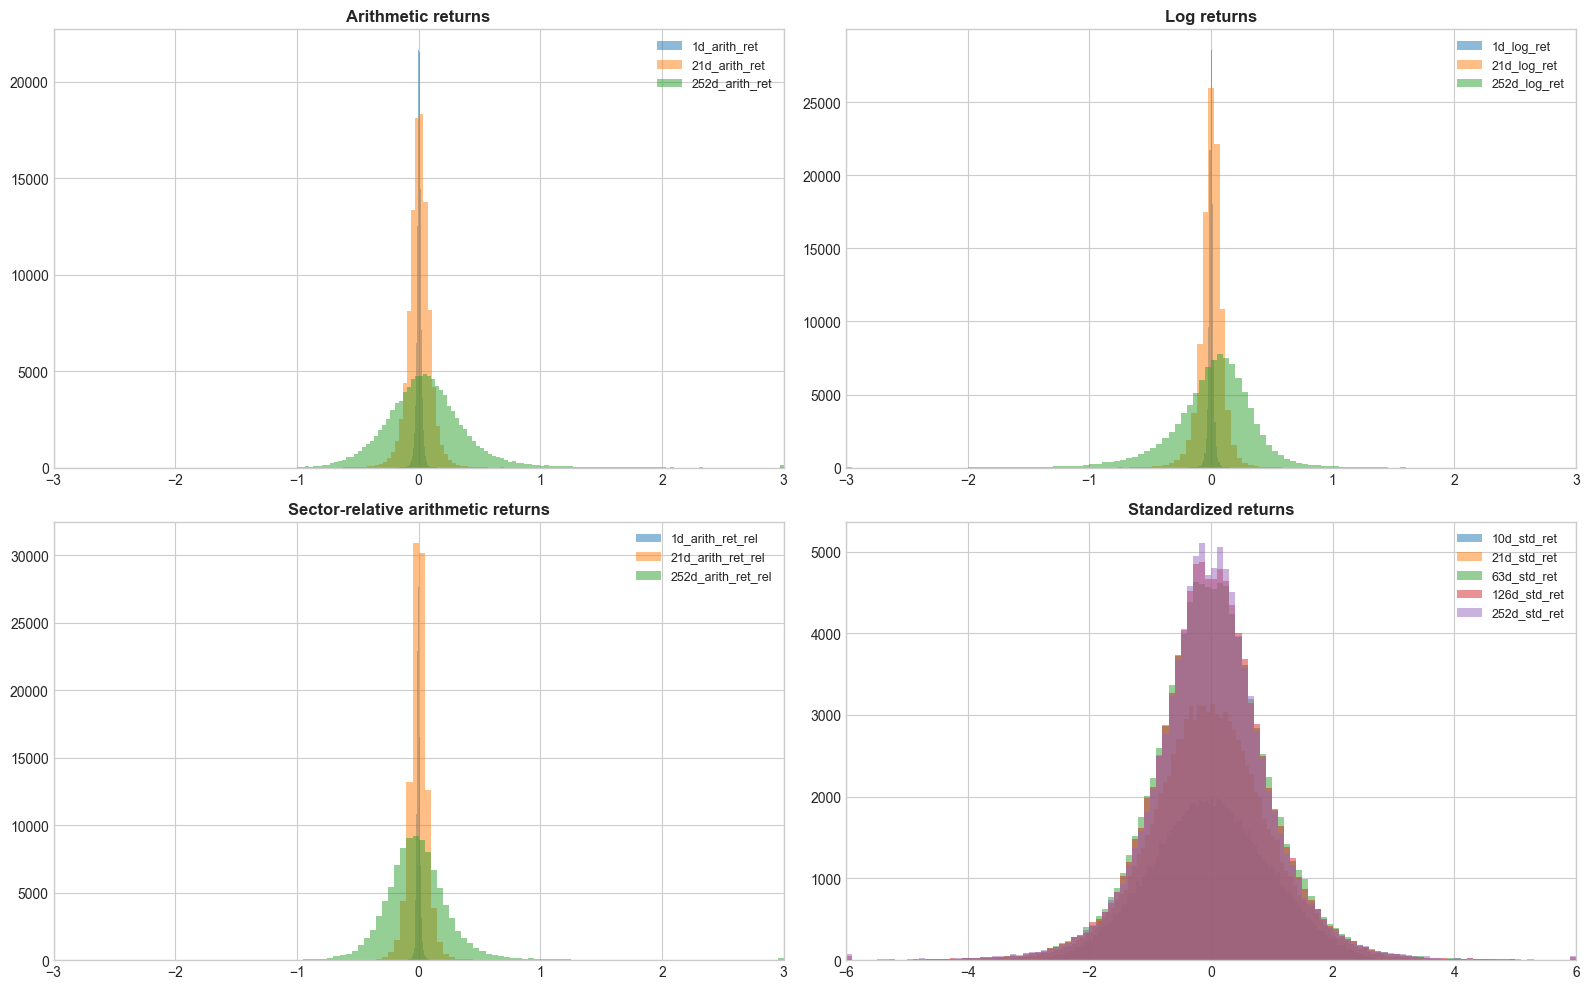

In [8]:
plot_configs = [
    {"title": "Arithmetic returns", "suffix": "_arith_ret", "clip": (-3, 3)}, 
    {"title": "Log returns", "suffix": "_log_ret", "clip": (-3, 3)},
    {"title": "Sector-relative arithmetic returns", "suffix": "_arith_ret_rel", "clip": (-3, 3)},
    {"title": "Standardized returns", "suffix": "_std_ret", "clip": (-6, 6)} 
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, config in enumerate(plot_configs):
    ax = axes[i]
    
    cols = [c for c in stocks.columns if c.endswith(config["suffix"])]
    
    for c in cols:
        s = stocks[c].dropna().clip(config["clip"][0], config["clip"][1])
        
        if len(s) > 100_000: 
            s = s.sample(100_000, random_state=0)
            
        ax.hist(s, bins=120, alpha=0.5, label=c)
        
    ax.set_title(config["title"], fontsize=12, fontweight="bold")
    ax.set_xlim(config["clip"][0], config["clip"][1])
    
    if cols: 
        ax.legend(loc="upper right", fontsize=9)

plt.tight_layout(); plt.show()

### Universe composition over time
 
Decompose the alive-universe count by region and by sector to see how the panel composition shifts. Useful for understanding which regimes the model will be exposed to.

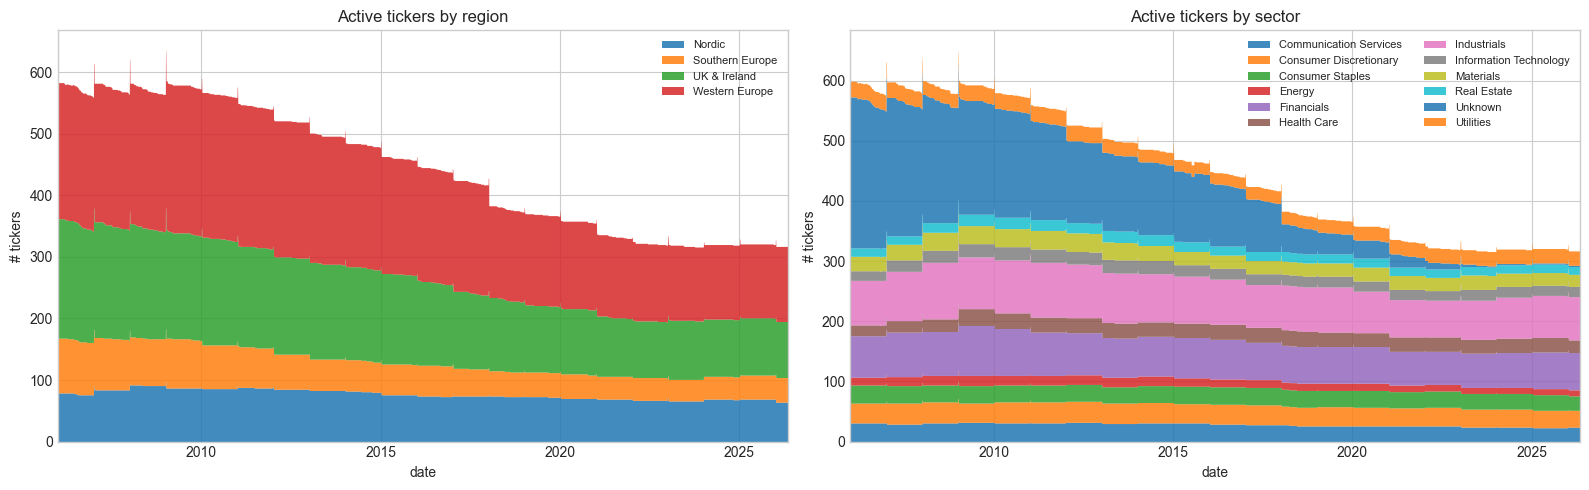

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

by_region = (stocks.groupby(["date", "region"])["ticker"]
                   .nunique().unstack(fill_value=0))
by_region.plot.area(ax=axes[0], linewidth=0, alpha=0.85)
axes[0].set_title("Active tickers by region")
axes[0].set_ylabel("# tickers"); axes[0].legend(loc="upper right", fontsize=8)

by_sector = (stocks.groupby(["date", "sector"])["ticker"]
                   .nunique().unstack(fill_value=0))
by_sector.plot.area(ax=axes[1], linewidth=0, alpha=0.85)
axes[1].set_title("Active tickers by sector")
axes[1].set_ylabel("# tickers"); axes[1].legend(loc="upper right", fontsize=8, ncol=2)

plt.tight_layout(); plt.show()

### Forward-fill and stale-price footprint
 
How frequently each cleaning flag fires across the panel. Spikes indicate either widespread market closures or data gaps localised in time.

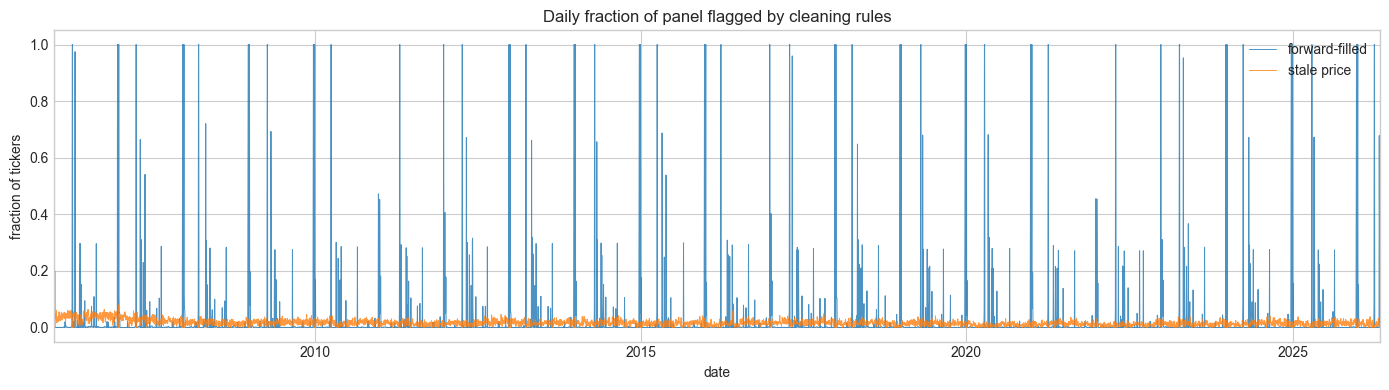

Overall ffill fraction: 3.03%
Overall stale fraction: 1.67%


In [11]:
flags_per_day = (stocks.groupby("date")[["is_ffilled", "is_stale"]].mean())  # fraction of tickers flagged on each date

fig, ax = plt.subplots(figsize=(14, 4))
flags_per_day.plot(ax=ax, linewidth=0.7, alpha=0.8)
ax.set_title("Daily fraction of panel flagged by cleaning rules")
ax.set_ylabel("fraction of tickers")
ax.legend(["forward-filled", "stale price"], loc="upper right")
plt.tight_layout(); plt.show()

print(f"Overall ffill fraction: {stocks['is_ffilled'].mean():.2%}")
print(f"Overall stale fraction: {stocks['is_stale'].mean():.2%}")